In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score, mean_absolute_error, mean_squared_error, r2_score

### Data Cleaning

In [2]:
# Read CSVs
data1 = pd.read_csv('ResaleFlatPricesBasedonRegistrationDateFromMar2012toDec2014.csv')
data2 = pd.read_csv('ResaleFlatPricesBasedonRegistrationDateFromJan2015toDec2016.csv')
data3 = pd.read_csv('ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

# Check the shape
print(data1.shape)
print(data2.shape)
print(data3.shape)

(52203, 10)
(37153, 11)
(228126, 11)


Standardise schema

In [3]:
# Add missing column in data1
data1['remaining_lease'] = pd.NA

# Add source flag to differentiate how remaining lease years is obtained
data1['lease_source'] = 'estimated'
data2['lease_source'] = 'original_year_only'
data3['lease_source'] = 'original_exact'

# Ensure same column order
cols = ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm',
        'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'lease_source']

data1 = data1[cols]
data2 = data2[cols]
data3 = data3[cols]

# Combine datasets
df = pd.concat([data1, data2, data3], ignore_index = True)

# Check the shape
print(df.shape)

(317482, 12)


In [4]:
# Check Data Types

print("Data Types")
print(df.dtypes)

Data Types
month                      str
town                       str
flat_type                  str
block                      str
street_name                str
storey_range               str
floor_area_sqm         float64
flat_model                 str
lease_commence_date      int64
remaining_lease         object
resale_price           float64
lease_source               str
dtype: object


In [5]:
# Check Missing Values

print("Missing Values (Count)")
print(df.isnull().sum())

Missing Values (Count)
month                      0
town                       0
flat_type                  0
block                      0
street_name                0
storey_range               0
floor_area_sqm             0
flat_model                 0
lease_commence_date        0
remaining_lease        52203
resale_price               0
lease_source               0
dtype: int64


In [6]:
# Check Duplicates

duplicates = df.duplicated().sum()
print("Number of duplicates:", duplicates)

Number of duplicates: 585


In [7]:
# Show original + duplicate pair

dup_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows (including originals):", len(dup_rows))
dup_rows.head(10)

Total duplicate rows (including originals): 1169


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,lease_source
336,2012-03,BUKIT BATOK,3 ROOM,212,BT BATOK ST 21,06 TO 10,67.0,New Generation,1985,<NA>,341000.0,estimated
337,2012-03,BUKIT BATOK,3 ROOM,212,BT BATOK ST 21,06 TO 10,67.0,New Generation,1985,<NA>,341000.0,estimated
2650,2012-04,BUKIT BATOK,3 ROOM,167,BT BATOK WEST AVE 8,01 TO 05,74.0,Model A,1984,<NA>,333000.0,estimated
2651,2012-04,BUKIT BATOK,3 ROOM,167,BT BATOK WEST AVE 8,01 TO 05,74.0,Model A,1984,<NA>,333000.0,estimated
3259,2012-04,JURONG EAST,3 ROOM,303,JURONG EAST ST 32,01 TO 05,67.0,New Generation,1983,<NA>,330000.0,estimated
3260,2012-04,JURONG EAST,3 ROOM,303,JURONG EAST ST 32,01 TO 05,67.0,New Generation,1983,<NA>,330000.0,estimated
4164,2012-04,WOODLANDS,3 ROOM,15,MARSILING LANE,01 TO 05,65.0,Improved,1976,<NA>,280000.0,estimated
4165,2012-04,WOODLANDS,3 ROOM,15,MARSILING LANE,01 TO 05,65.0,Improved,1976,<NA>,280000.0,estimated
4420,2012-04,YISHUN,3 ROOM,740,YISHUN AVE 5,06 TO 10,67.0,New Generation,1985,<NA>,341000.0,estimated
4421,2012-04,YISHUN,3 ROOM,740,YISHUN AVE 5,06 TO 10,67.0,New Generation,1985,<NA>,341000.0,estimated


In [8]:
# Remove duplicates
df = df.drop_duplicates()

# Check again
print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 316897 entries, 0 to 317481
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                316897 non-null  str    
 1   town                 316897 non-null  str    
 2   flat_type            316897 non-null  str    
 3   block                316897 non-null  str    
 4   street_name          316897 non-null  str    
 5   storey_range         316897 non-null  str    
 6   floor_area_sqm       316897 non-null  float64
 7   flat_model           316897 non-null  str    
 8   lease_commence_date  316897 non-null  int64  
 9   remaining_lease      264942 non-null  object 
 10  resale_price         316897 non-null  float64
 11  lease_source         316897 non-null  str    
dtypes: float64(2), int64(1), object(1), str(8)
memory usage: 31.4+ MB


Calculate remaining lease years

In [10]:
# Convert remaining lease into numeric
def convert_lease_to_years(x):
    if pd.isna(x):
        return np.nan

    x = str(x)
    
    # Case 1: only number (e.g. "60") (data2)
    if x.isdigit():
        return int(x)
    
    # Case 2: contain "year" and "month"
    # Extract years
    years_match = re.search(r'(\d+)\s*year', x)
    years = int(years_match.group(1)) if years_match else 0
    # Extract months
    months_match = re.search(r'(\d+)\s*month', x)
    months = int(months_match.group(1)) if months_match else 0

    return (years + (months / 12))

df['remaining_lease_years'] = df['remaining_lease'].apply(convert_lease_to_years)

In [11]:
# Estimate remaining lease years for data1 records

# Convert string to datetime
df['month'] = pd.to_datetime(df['month'])

# Extract transaction year and month
df['transaction_year'] = df['month'].dt.year
df['transaction_month'] = df['month'].dt.month

# Assume lease starts mid-year (June = 6) as exact start month not available
ASSUMED_START_MONTH = 6

year_diff = df['transaction_year'] - df['lease_commence_date']
month_adjustment = (df['transaction_month'] - ASSUMED_START_MONTH) / 12

estimated_lease = 99 - (year_diff + month_adjustment)

# Fill only missing values from data1
mask = df['lease_source'] == 'estimated'
df.loc[mask, 'remaining_lease_years'] = df.loc[mask, 'remaining_lease_years'].fillna(estimated_lease)

Find mid value of storey range

In [12]:
def extract_storey_mid(x):
    try:
        low, high = x.split(' TO ')
        return (int(low) + int(high)) / 2
    except:
        return np.nan

df['storey_mid'] = df['storey_range'].apply(extract_storey_mid)

Final Check

In [13]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 316897 entries, 0 to 317481
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   month                  316897 non-null  datetime64[us]
 1   town                   316897 non-null  str           
 2   flat_type              316897 non-null  str           
 3   block                  316897 non-null  str           
 4   street_name            316897 non-null  str           
 5   storey_range           316897 non-null  str           
 6   floor_area_sqm         316897 non-null  float64       
 7   flat_model             316897 non-null  str           
 8   lease_commence_date    316897 non-null  int64         
 9   remaining_lease        264942 non-null  object        
 10  resale_price           316897 non-null  float64       
 11  lease_source           316897 non-null  str           
 12  remaining_lease_years  316897 non-null  float64       
 13  

,month,floor_area_sqm,lease_commence_date,resale_price,remaining_lease_years,transaction_year,transaction_month,storey_mid
count,316897,316897.000000,316897.000000,3.168970e+05,316897.000000,316897.000000,316897.000000,316897.000000
mean,2019-09-29 06:04:16.217004,96.683744,1994.693806,5.064654e+05,74.375283,2019.281341,6.554382,8.524243
min,2012-03-01 00:00:00,31.000000,1966.000000,1.400000e+05,39.750000,2012.000000,1.000000,2.000000
25%,2016-06-01 00:00:00,75.000000,1984.000000,3.770000e+05,63.666667,2016.000000,4.000000,5.000000
50%,2020-03-01 00:00:00,93.000000,1994.000000,4.700000e+05,73.750000,2020.000000,7.000000,8.000000
75%,2023-03-01 00:00:00,112.000000,2004.000000,6.010000e+05,85.916667,2023.000000,9.000000,11.000000
max,2026-03-01 00:00:00,366.700000,2021.000000,1.700000e+06,98.250000,2026.000000,12.000000,50.000000
std,NaN,24.205468,13.661627,1.772546e+05,13.317594,4.042454,3.380727,5.738532


In [14]:
# Logical Data Checks

print("\n=== Invalid Remaining Lease ===")
print(df[df['remaining_lease_years'] <= 0].shape)

print("\n=== Unrealistic Floor Area (> 300 sqm) ===")
print(df[df['floor_area_sqm'] > 300].shape)

print("\n=== Negative Prices ===")
print(df[df['resale_price'] <= 0].shape)


=== Invalid Remaining Lease ===
(0, 16)

=== Unrealistic Floor Area (> 300 sqm) ===
(1, 16)

=== Negative Prices ===
(0, 16)


In [15]:
df[df['floor_area_sqm'] > 300]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,lease_source,remaining_lease_years,transaction_year,transaction_month,storey_mid
272179,2024-07-01,KALLANG/WHAMPOA,3 ROOM,53,JLN MA'MOR,01 TO 03,366.7,Terrace,1972,47 years,1568000.0,original_exact,47.0,2024,7,2.0


In [16]:
# =========================
# Summary Statistics
# =========================

print("\n=== Summary Statistics ===")
print(df[['resale_price', 'floor_area_sqm', 'remaining_lease_years']].describe())


=== Summary Statistics ===
       resale_price  floor_area_sqm  remaining_lease_years
count  3.168970e+05   316897.000000          316897.000000
mean   5.064654e+05       96.683744              74.375283
std    1.772546e+05       24.205468              13.317594
min    1.400000e+05       31.000000              39.750000
25%    3.770000e+05       75.000000              63.666667
50%    4.700000e+05       93.000000              73.750000
75%    6.010000e+05      112.000000              85.916667
max    1.700000e+06      366.700000              98.250000


### 1. Market overview
How have HDB resale prices changed over time?
Is the market rising, stable, or volatile?

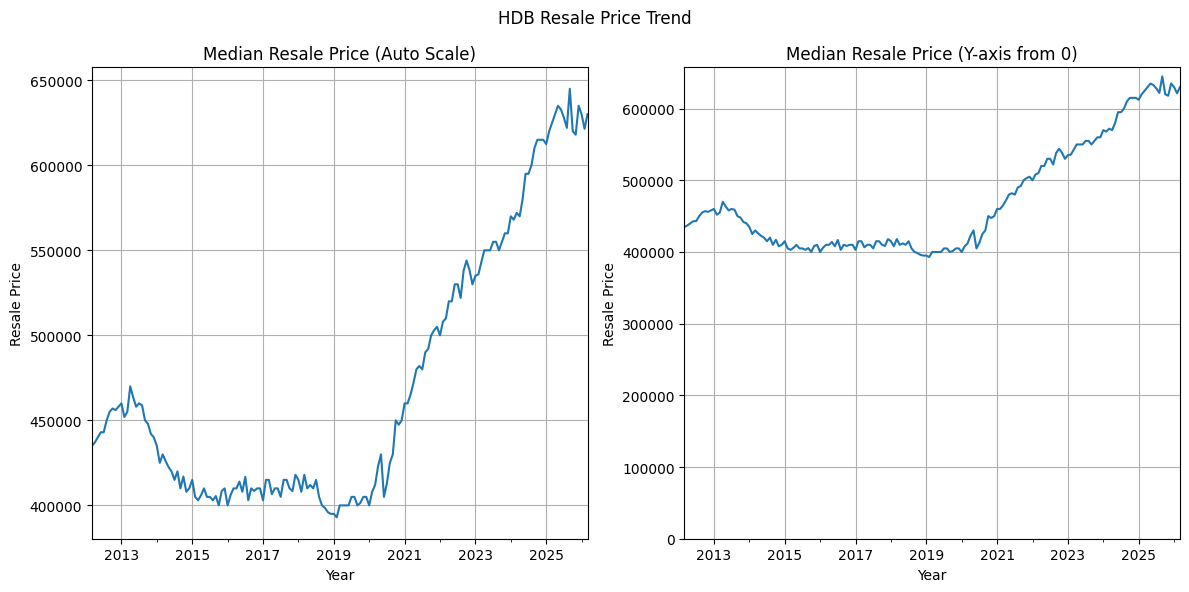

In [17]:
# Median monthly resale price, less affected by outliers
monthly_prices = df.groupby('month')['resale_price'].median()

fig, axes = plt.subplots(1, 2, figsize = (12, 6))
fig.suptitle("HDB Resale Price Trend")

monthly_prices.plot(ax = axes[0])
axes[0].set_title("Median Resale Price (Auto Scale)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Resale Price")
axes[0].grid(True)

monthly_prices.plot(ax = axes[1])
axes[1].set_title("Median Resale Price (Y-axis from 0)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Resale Price")
axes[1].set_ylim(bottom = 0)
axes[1].grid()

plt.tight_layout()
plt.show()

Mean vs Median Resale Price over Time

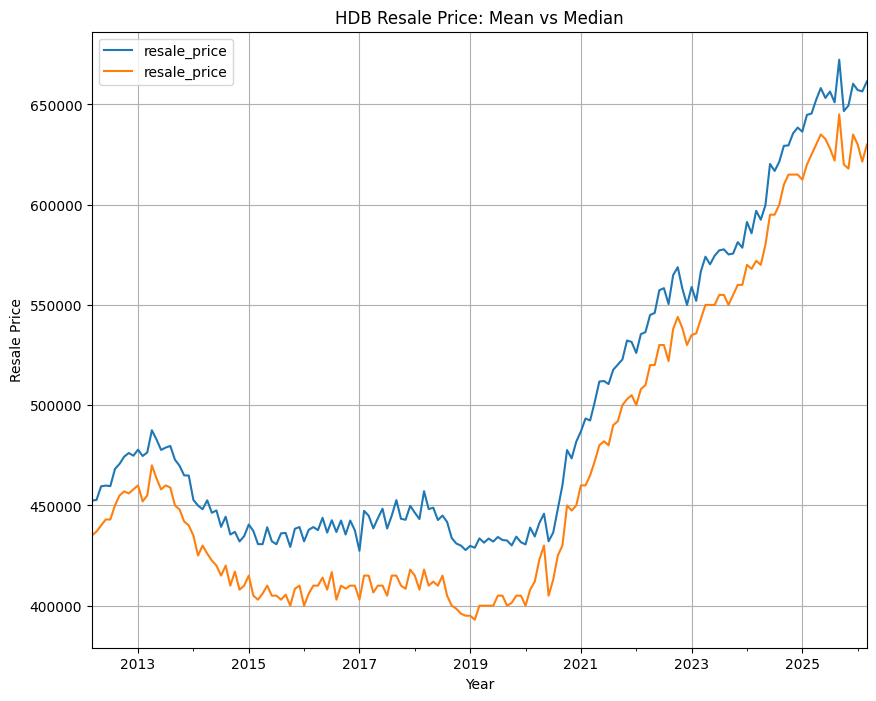

In [18]:
# Mean vs Median Resale Price over Time
fig, ax = plt.subplots(figsize = (10, 8))

df.groupby('month')['resale_price'].mean().plot(ax = ax)
df.groupby('month')['resale_price'].median().plot(ax = ax)
ax.set_title("HDB Resale Price: Mean vs Median")
ax.set_xlabel("Year")
ax.set_ylabel("Resale Price")
ax.legend()
ax.grid(True)

plt.show()

Flat Type Resale Price over Time

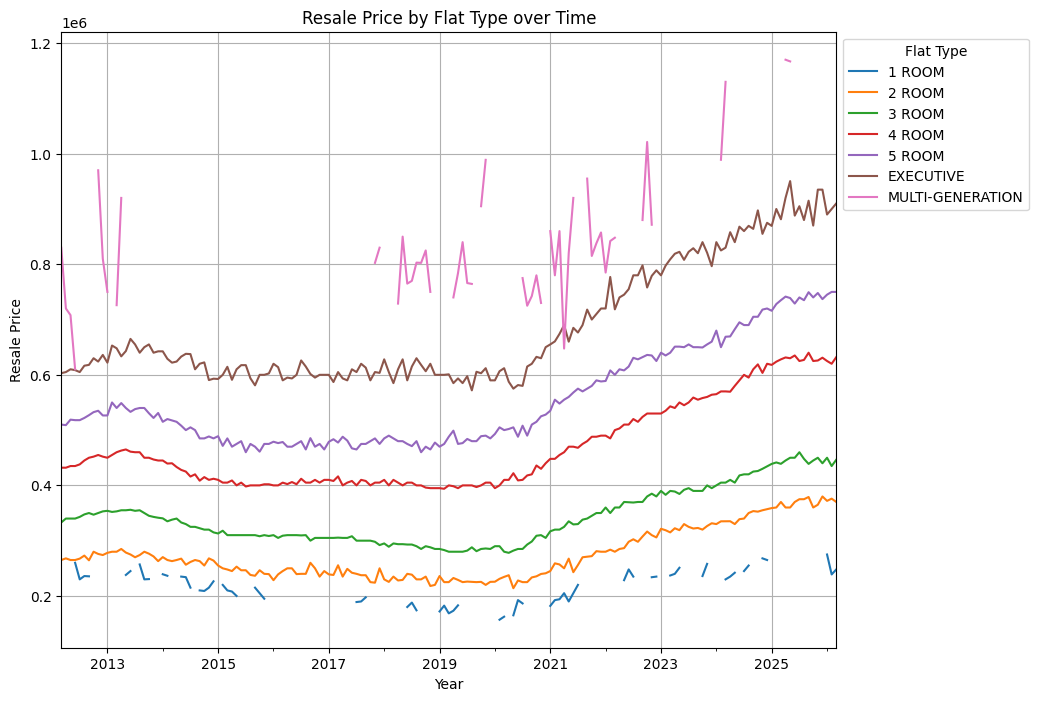

In [19]:
flat_type_resale_price = df.groupby(['month', 'flat_type'])['resale_price'].median().unstack()

fig, ax = plt.subplots(figsize = (10, 8))

flat_type_resale_price.plot(ax = ax)

ax.set_title("Resale Price by Flat Type over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Resale Price")
ax.grid(True)
ax.legend(title = 'Flat Type', loc = 'upper left', bbox_to_anchor=(1, 1))

plt.show()

Text(0.5, 0, 'Price')

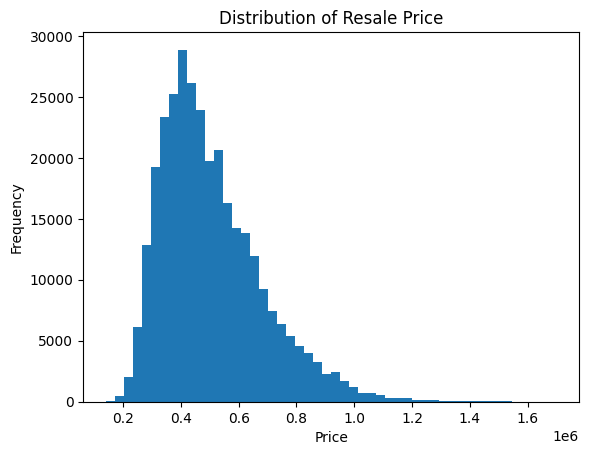

In [20]:
# df['resale_price'].plot(kind='hist', bins=50)

fig, ax = plt.subplots()
df['resale_price'].plot(kind='hist', bins=50, ax=ax)
ax.set_title("Distribution of Resale Price")
ax.set_xlabel("Price")

### 2. Location impact
Which towns are most expensive?
Which towns are growing fastest?

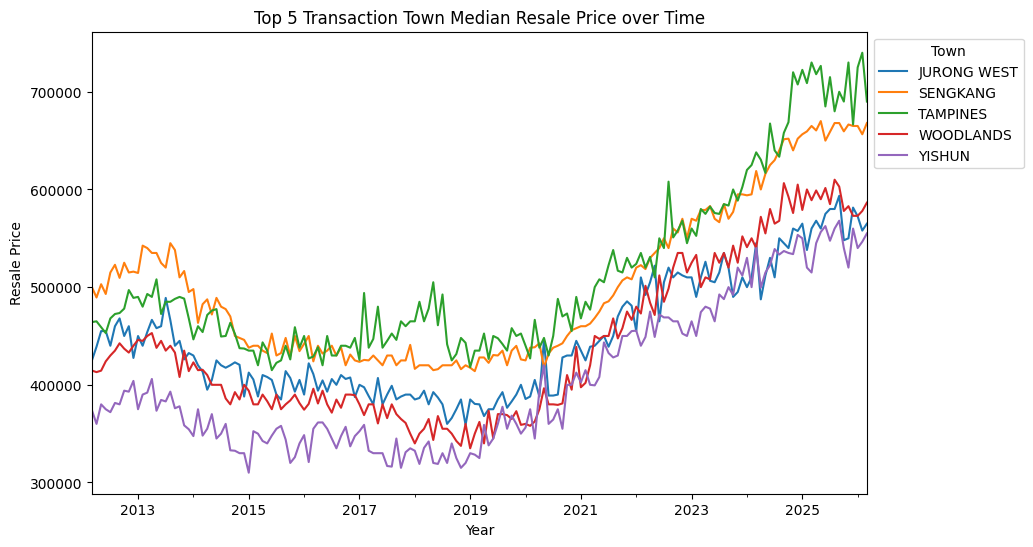

In [21]:
# Top 5 transaction towns
top_towns = df['town'].value_counts().head(5).index

fig, ax = plt.subplots(figsize = (10, 6))

df[df['town'].isin(top_towns)].groupby(['month', 'town'])['resale_price'].median().unstack().plot(ax = ax)

ax.set_title("Top 5 Transaction Town Median Resale Price over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Resale Price")
ax.legend(title = "Town", loc = "upper left", bbox_to_anchor = (1, 1))

plt.show()

Top 5 Average Resale Price Towns

In [22]:
# Top 5 average resale price towns
expensive_towns = df.groupby('town')['resale_price'].mean().sort_values(ascending = False)

top_expensive = expensive_towns.head(5)
print(top_expensive)

town
BUKIT TIMAH     754230.115585
BISHAN          677246.881003
CENTRAL AREA    661437.747605
BUKIT MERAH     613378.014342
QUEENSTOWN      605750.307309
Name: resale_price, dtype: float64


Resale Price Growth

In [23]:
# Resale price growth 
resale_price_by_town = df.groupby(['transaction_year', 'town'])['resale_price'].mean().reset_index()

pivot = resale_price_by_town.pivot(index='transaction_year', columns='town', values='resale_price')

growth = (pivot.iloc[-1] / pivot.iloc[0]) - 1
growth = growth.dropna()
growth = growth.sort_values(ascending=False)

top_growth = growth.head(5)
print(top_growth)

town
CENTRAL AREA       0.667364
KALLANG/WHAMPOA    0.624699
QUEENSTOWN         0.598918
ANG MO KIO         0.592506
TOA PAYOH          0.562831
dtype: float64


In [24]:
# Top 5 average yearly percentage growth in resale price
growth_yoy = pivot.pct_change()

growth_yoy = growth_yoy.dropna()

avg_growth = growth_yoy.mean().sort_values(ascending=False)
print(avg_growth.head(5))

town
CENTRAL AREA       0.046518
KALLANG/WHAMPOA    0.037354
TOA PAYOH          0.036030
ANG MO KIO         0.035988
QUEENSTOWN         0.034870
dtype: float64


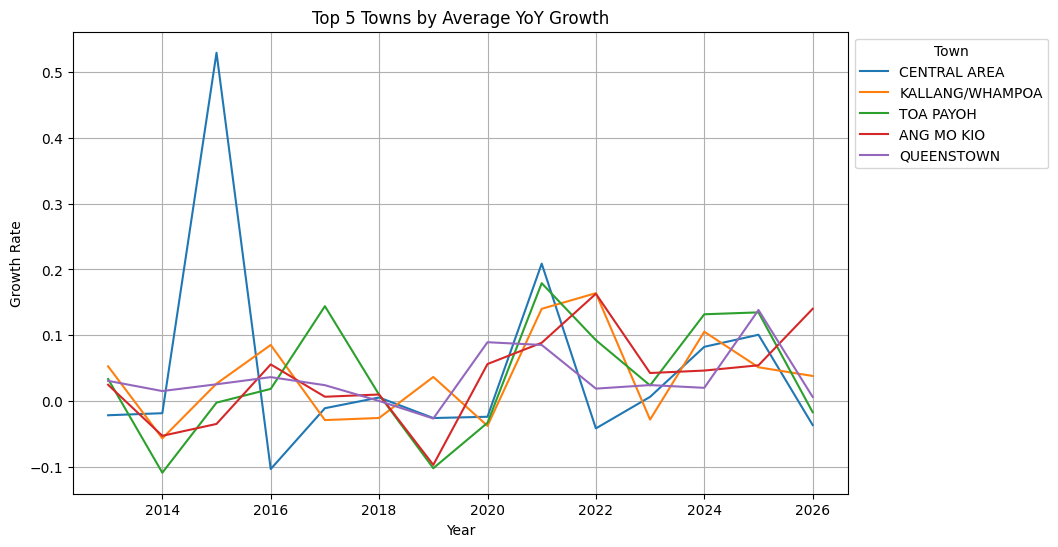

In [25]:
avg_growth = growth_yoy.mean().sort_values(ascending=False)

top_towns = avg_growth.head(5).index

fig, ax = plt.subplots(figsize=(10, 6))
growth_yoy[top_towns].plot(ax=ax)

ax.set_title("Top 5 Towns by Average YoY Growth")
ax.set_xlabel("Year")
ax.set_ylabel("Growth Rate")
ax.grid(True)
ax.legend(title = "Town", loc = "upper left", bbox_to_anchor = (1, 1))

plt.show()

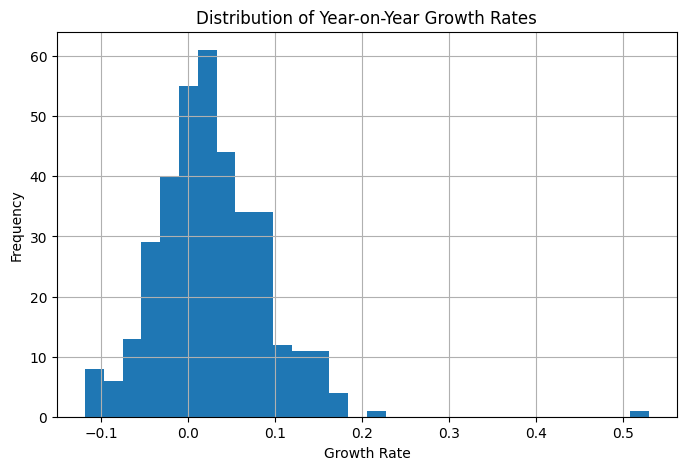

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

growth_yoy.stack().hist(ax=ax, bins=30)

ax.set_title("Distribution of Year-on-Year Growth Rates")
ax.set_xlabel("Growth Rate")
ax.set_ylabel("Frequency")

plt.show()

### 3. Property characteristics
How does price vary by:
Flat type (3-room, 4-room, etc.)
Floor area
Remaining lease

Price vs Flat Type

In [27]:
# Mean resale price by flat type
flat_type_prices = df.groupby('flat_type')['resale_price'].mean().sort_values()
print(flat_type_prices)

flat_type
1 ROOM              217521.558824
2 ROOM              296156.368130
3 ROOM              363671.545606
4 ROOM              510330.314406
5 ROOM              603410.197530
EXECUTIVE           704966.766407
MULTI-GENERATION    838474.918919
Name: resale_price, dtype: float64


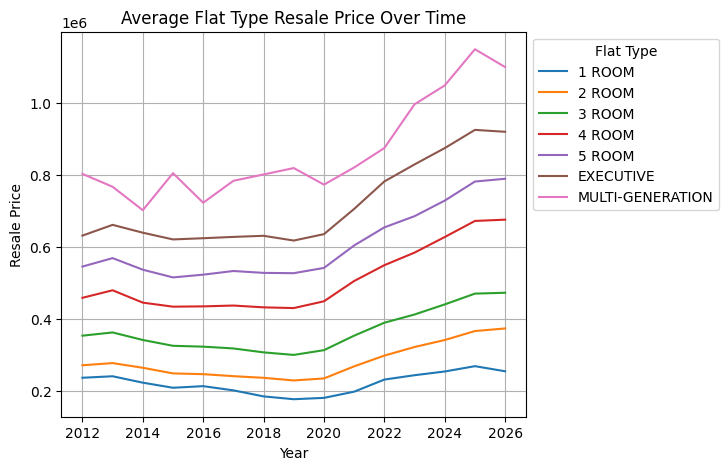

In [28]:
fig, ax = plt.subplots(figsize = (6, 5))

df.groupby(['transaction_year', 'flat_type'])['resale_price'].mean().unstack().plot(ax = ax)

ax.set_title("Average Flat Type Resale Price Over Time")
ax.set_ylabel("Resale Price")
ax.set_xlabel("Year")
ax.legend(title = "Flat Type", loc = "upper left", bbox_to_anchor = (1, 1))
ax.grid(True)

plt.show()

Price vs Floor Area

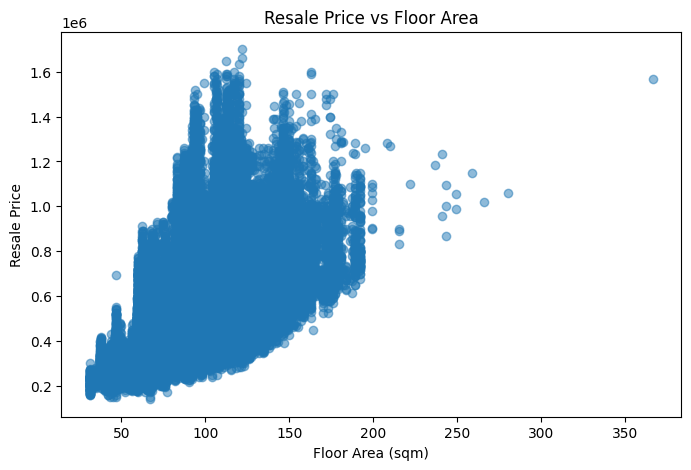

Correlation: 0.5778416863459328


In [29]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(df['floor_area_sqm'], df['resale_price'], alpha=0.5)
ax.set_title('Resale Price vs Floor Area')
ax.set_xlabel('Floor Area (sqm)')
ax.set_ylabel('Resale Price')

plt.show()

# Correlation
print("Correlation:", df['floor_area_sqm'].corr(df['resale_price']))

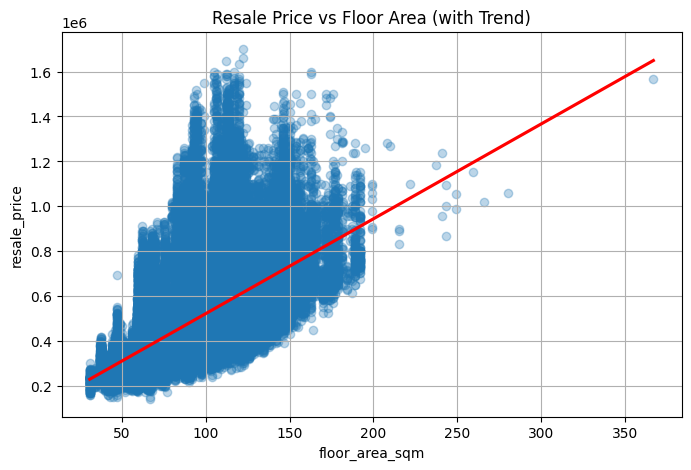

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(
    data=df,
    x='floor_area_sqm',
    y='resale_price',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    ax=ax
)

ax.set_title("Resale Price vs Floor Area (with Trend)")
ax.grid(True)

plt.show()

Price vs Remaining Lease

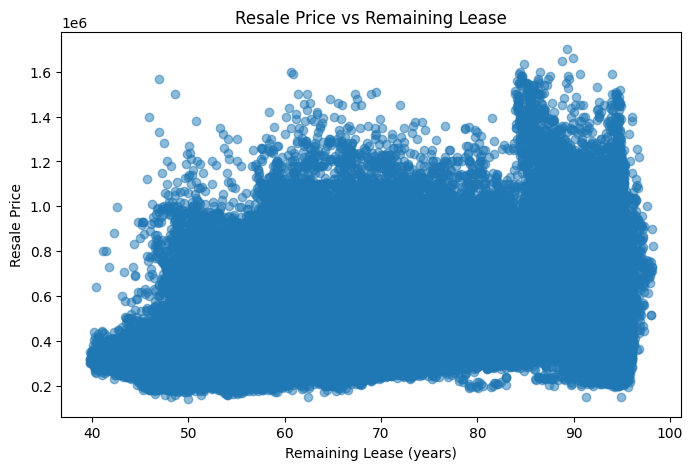

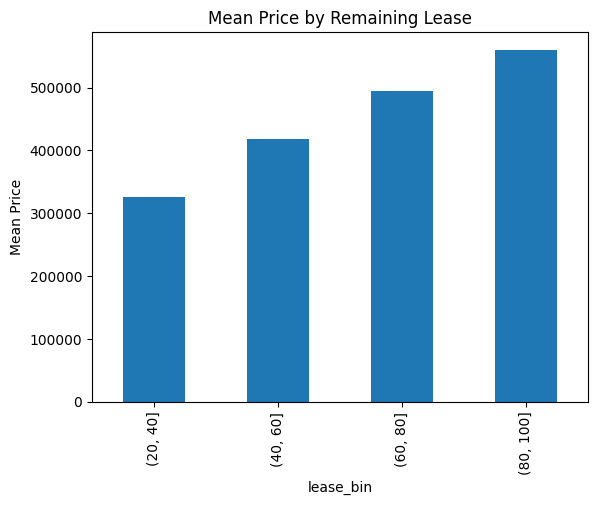

In [31]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(df['remaining_lease_years'], df['resale_price'], alpha=0.5)
ax.set_title('Resale Price vs Remaining Lease')
ax.set_xlabel('Remaining Lease (years)')
ax.set_ylabel('Resale Price')

plt.show()

# Optional: bin and median
lease_bins = [0, 20, 40, 60, 80, 100]
df['lease_bin'] = pd.cut(df['remaining_lease_years'], bins=lease_bins)
lease_prices = df.groupby('lease_bin')['resale_price'].mean()
lease_prices.plot(kind='bar', title='Mean Price by Remaining Lease')
plt.ylabel('Mean Price')
plt.show()

### 4. Key drivers
Which factors influence price the most?
Size?
Location?
Lease?

In [32]:
# Drop this for ML focused story
# df.corr(numeric_only=True)

In [33]:
# Define features and target
X = df[['town', 'flat_type', 'storey_mid', 'floor_area_sqm', 'flat_model', 'remaining_lease_years']]
y = df['resale_price']

# One-hot encode categorical variables
categorical_features = ['town', 'flat_type', 'flat_model']
numeric_features = ['storey_mid', 'floor_area_sqm', 'remaining_lease_years']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])

model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [34]:
# Standardized linear model coefficients (effect size proxy)
# Extract coefficients
coef_df = pd.DataFrame({
    'feature': model.named_steps['preprocessor'].get_feature_names_out(),
    'coefficient': model.named_steps['regressor'].coef_
})

# Sort by absolute impact
coef_df = coef_df.sort_values(by='coefficient', key=abs, ascending=False)

print(coef_df.head(10))

                             feature    coefficient
51           cat__flat_model_Terrace  302060.562633
31             cat__flat_type_5 ROOM  299099.260705
32          cat__flat_type_EXECUTIVE  291811.440002
30             cat__flat_type_4 ROOM  212552.919953
33   cat__flat_type_MULTI-GENERATION  187693.361512
44  cat__flat_model_Multi Generation  187693.361512
8              cat__town_BUKIT TIMAH  185436.624932
53           cat__flat_model_Type S2  170219.326280
52           cat__flat_model_Type S1  164286.821840
10           cat__town_CHOA CHU KANG -157972.307275


In [35]:
# Extract TRUE original feature names (removes num__/cat__ AND one-hot suffix logic safely)
# coef_df['original_feature'] = coef_df['feature'].str.split('__').str[1]
coef_df['original_feature'] = coef_df['feature'].apply(
    lambda x: x.split('__')[1].split('_')[0] if x.startswith('cat__') else x.split('__')[1]
)

# Group importance correctly
importance = (
    coef_df.groupby('original_feature')['coefficient']
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
)

print("Feature importance (by original variables):")
print(importance)

Feature importance (by original variables):
original_feature
flat                     3.186819e+06
town                     2.268339e+06
floor_area_sqm           4.701078e+04
remaining_lease_years    3.750002e+04
storey_mid               3.237137e+04
Name: coefficient, dtype: float64


In [36]:
print("Top drivers of resale price:")
print(importance.head(10))

Top drivers of resale price:
original_feature
flat                     3.186819e+06
town                     2.268339e+06
floor_area_sqm           4.701078e+04
remaining_lease_years    3.750002e+04
storey_mid               3.237137e+04
Name: coefficient, dtype: float64


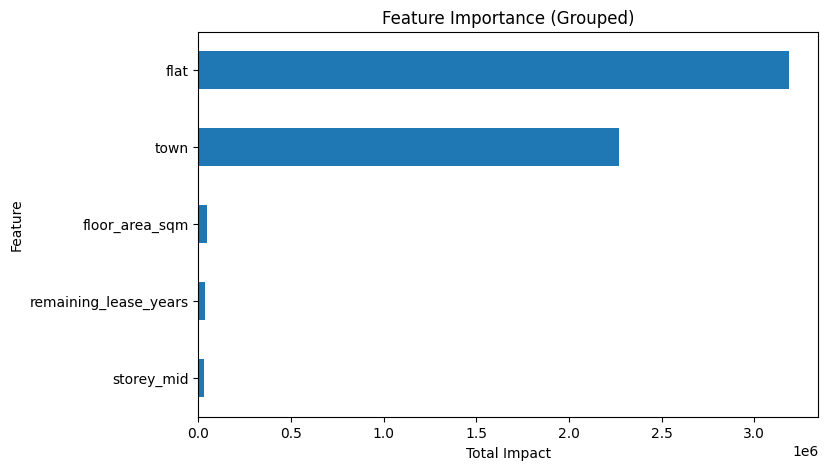

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

importance.sort_values().plot(kind='barh', ax=ax)

ax.set_title("Feature Importance (Grouped)")
ax.set_xlabel("Total Impact")
ax.set_ylabel("Feature")

plt.show()

### Clean for modelling

In [38]:
df = df.dropna(subset=[
    'town', 'flat_type', 'storey_mid',
    'floor_area_sqm', 'flat_model', 'remaining_lease_years', 'resale_price'
])

### Price classification

Since the dataset is time-based, avoid random splitting to prevent temporal leakage. Used a chronological split instead so the model is always evaluated on future data.

In [39]:
# Step 1: Split first
df_class = df.sort_values('month')

split_idx = int(len(df_class) * 0.8)

train_df = df_class.iloc[:split_idx]
test_df = df_class.iloc[split_idx:]

train_df = train_df.copy()
test_df = test_df.copy()

In [40]:
# Step 2: Create price classes using TRAIN thresholds
# compute thresholds on train
q1 = train_df['resale_price'].quantile(0.33)
q2 = train_df['resale_price'].quantile(0.66)

def classify_price(p):
    if p <= q1:
        return 0  # Low
    elif p <= q2:
        return 1  # Medium
    else:
        return 2  # High

train_df['price_class'] = train_df['resale_price'].apply(classify_price)
test_df['price_class'] = test_df['resale_price'].apply(classify_price)

In [41]:
train_df['price_class'].value_counts()

price_class
0    86137
2    84786
1    82594
Name: count, dtype: int64

In [42]:
# Step 3: Define X and y

features = ['town', 'flat_type', 'storey_mid', 'floor_area_sqm', 'flat_model', 'remaining_lease_years']

X_train = train_df[features]
y_train = train_df['price_class']

X_test = test_df[features]
y_test = test_df['price_class']

In [43]:
categorical = ['town', 'flat_type', 'flat_model']
numeric = ['storey_mid', 'floor_area_sqm', 'remaining_lease_years']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [44]:
# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.39256863363837174
              precision    recall  f1-score   support

           0       0.26      1.00      0.42      6077
           1       0.04      0.07      0.05     12298
           2       1.00      0.40      0.57     45005

    accuracy                           0.39     63380
   macro avg       0.43      0.49      0.34     63380
weighted avg       0.74      0.39      0.45     63380



In [45]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 6076     1     0]
 [11438   831    29]
 [ 5645 21386 17974]]


In [46]:
# Predicted probabilities
y_prob = model.predict_proba(X_test)

In [47]:
# Step 9: Feature Importance (correct for multiclass)

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance = np.mean(np.abs(model.named_steps['classifier'].coef_), axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)


Feature Importance:
                                   Feature  Importance
8                    cat__town_BUKIT TIMAH    2.590693
21                     cat__town_SEMBAWANG    2.477367
26                     cat__town_WOODLANDS    2.442316
37                    cat__flat_model_DBSS    2.333330
10                 cat__town_CHOA CHU KANG    2.318994
15                   cat__town_JURONG WEST    2.176974
51                 cat__flat_model_Terrace    2.151198
7                  cat__town_BUKIT PANJANG    2.066771
9                   cat__town_CENTRAL AREA    1.937373
17                 cat__town_MARINE PARADE    1.928233
22                      cat__town_SENGKANG    1.865416
27                        cat__town_YISHUN    1.792934
19                       cat__town_PUNGGOL    1.619012
28                   cat__flat_type_2 ROOM    1.579862
20                    cat__town_QUEENSTOWN    1.463204
18                     cat__town_PASIR RIS    1.445968
32                cat__flat_type_EXECUTIVE  

### Cluster towns or flats
“Are there natural groups of properties?”

In [48]:
# Feature selection
features = ['floor_area_sqm', 'remaining_lease_years', 'storey_mid']

X = df[features].dropna()

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
# Elbow method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

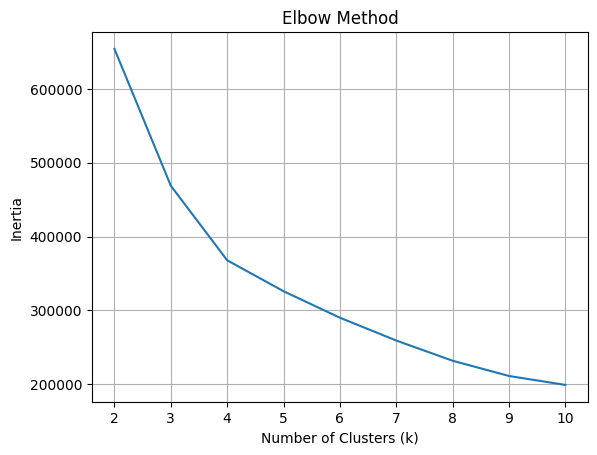

In [51]:
# Plot elbow
fig, ax = plt.subplots()
ax.plot(range(2, 11), inertia)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method')
ax.grid(True)
plt.show()

In [52]:
# Silhouette scores
sil_scores = {}

for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(5000, len(X_scaled)),
        random_state=42
    )

    sil_scores[k] = score

print("Silhouette Scores:", sil_scores)

Silhouette Scores: {3: 0.3324237053300468, 4: 0.3325403509724516, 5: 0.33089062975564704}


In [53]:
# Choose best k
best_k = max(sil_scores, key=sil_scores.get)
print("Best k:", best_k)

Best k: 4


In [54]:
# Fit final model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Assign clusters back safely
df['cluster'] = np.nan
df.loc[X.index, 'cluster'] = clusters

# Cluster size
print(df['cluster'].value_counts())

cluster
2.0    98291
1.0    97084
0.0    75119
3.0    46403
Name: count, dtype: int64


In [55]:
# Cluster profiling
full_profile = df.groupby('cluster')[features + ['resale_price']].mean()
print("Cluster Profile:")
print(full_profile)

Cluster Profile:
         floor_area_sqm  remaining_lease_years  storey_mid   resale_price
cluster                                                                  
0.0           93.759755              88.455572    6.779310  517747.378179
1.0           73.567076              60.773777    6.858689  368609.713237
2.0          121.533645              71.274043    6.855846  576312.480982
3.0           97.144581              86.607579   18.367670  628672.270128


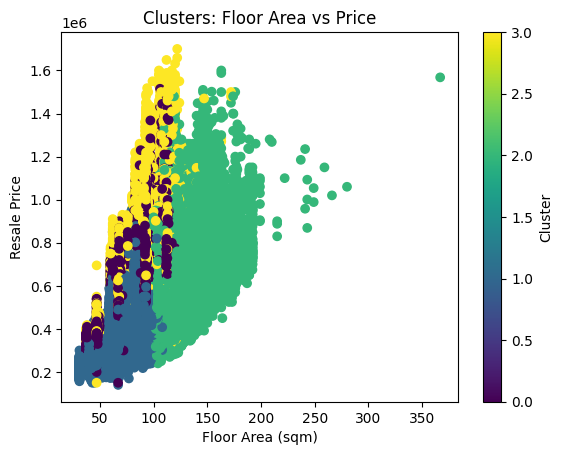

In [56]:
# Visualisation: Floor Area vs Price
fig, ax = plt.subplots()
scatter = ax.scatter(df['floor_area_sqm'], df['resale_price'], c=df['cluster'])
ax.set_xlabel('Floor Area (sqm)')
ax.set_ylabel('Resale Price')
ax.set_title('Clusters: Floor Area vs Price')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

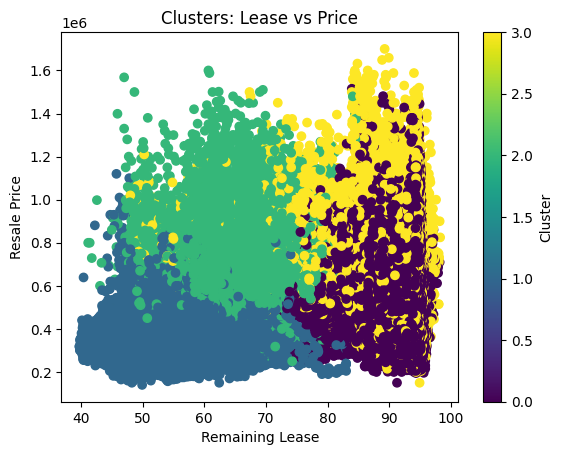

In [57]:
# Visualisation: Lease vs Price
fig, ax = plt.subplots()
scatter = ax.scatter(df['remaining_lease_years'], df['resale_price'], c=df['cluster'])
ax.set_xlabel('Remaining Lease')
ax.set_ylabel('Resale Price')
ax.set_title('Clusters: Lease vs Price')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

Explained variance: [0.43861434 0.33291013]


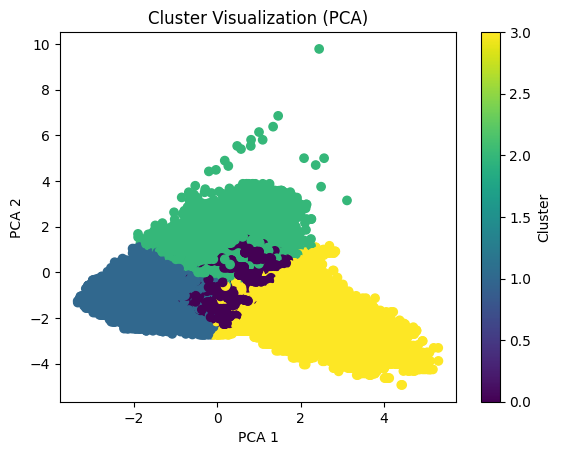

In [58]:
# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)


fig, ax = plt.subplots()
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_title('Cluster Visualization (PCA)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

### Resale Price prediction

In [59]:
# Sort by date
df = df.sort_values('month').reset_index(drop=True)

In [60]:
# Features and target
X = df[['town', 'flat_type', 'storey_mid', 'floor_area_sqm', 'flat_model', 'remaining_lease_years']]
y = df['resale_price']

In [61]:
# Define columns
categorical_cols = ['town', 'flat_type', 'flat_model']
numerical_cols = ['storey_mid', 'floor_area_sqm', 'remaining_lease_years']

In [62]:
# Preprocessors
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

preprocessor_rf = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

In [63]:
# Pipelines
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        n_jobs=-1,
        random_state=42
    ))
])

In [64]:
# =========================
# Time Series Cross Validation
# =========================

tscv = TimeSeriesSplit(n_splits=5)

lr_scores = []
rf_scores = []
mae_scores = []
rmse_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train
    lr_pipeline.fit(X_train, y_train)
    rf_pipeline.fit(X_train, y_train)

    # Predict
    y_pred_lr = lr_pipeline.predict(X_test)
    y_pred_rf = rf_pipeline.predict(X_test)

    # Metrics
    lr_r2 = r2_score(y_test, y_pred_lr)
    rf_r2 = r2_score(y_test, y_pred_rf)

    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

    print("Linear Regression R2:", lr_r2)
    print("Random Forest R2:", rf_r2)
    print("RF MAE:", rf_mae)
    print("RF RMSE:", rf_rmse)

    lr_scores.append(lr_r2)
    rf_scores.append(rf_r2)
    mae_scores.append(rf_mae)
    rmse_scores.append(rf_rmse)

    last_y_test = y_test
    last_y_pred_rf = y_pred_rf

===== Fold 0 =====


c:\Users\Chew\Downloads\project\proj\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Chew\Downloads\project\proj\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Linear Regression R2: 0.8101810519700169
Random Forest R2: 0.7743628959086
RF MAE: 51604.64886949881
RF RMSE: 66583.21658734638
===== Fold 1 =====
Linear Regression R2: 0.8359485550776213
Random Forest R2: 0.855968896753042
RF MAE: 45167.96229123242
RF RMSE: 58869.0857245665
===== Fold 2 =====
Linear Regression R2: 0.766511220051599
Random Forest R2: 0.8197265573744721
RF MAE: 51392.07994315401
RF RMSE: 69298.00228045533
===== Fold 3 =====


c:\Users\Chew\Downloads\project\proj\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Chew\Downloads\project\proj\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Linear Regression R2: 0.33476580662774835
Random Forest R2: 0.5613411449706316
RF MAE: 97636.26198602968
RF RMSE: 115022.03522824489
===== Fold 4 =====
Linear Regression R2: 0.033875721985205054
Random Forest R2: 0.46513576012729074
RF MAE: 118932.59945961737
RF RMSE: 146264.82156564284


In [65]:
# =========================
# Final Performance Summary
# =========================
print("===== Average Performance =====")
print("LR Avg R2:", np.mean(lr_scores))
print("RF Avg R2:", np.mean(rf_scores))
print("RF Avg MAE:", np.mean(mae_scores))
print("RF Avg RMSE:", np.mean(rmse_scores))

===== Average Performance =====
LR Avg R2: 0.556256471142438
RF Avg R2: 0.6953070510268073
RF Avg MAE: 72946.71050990645
RF Avg RMSE: 91207.43227725118


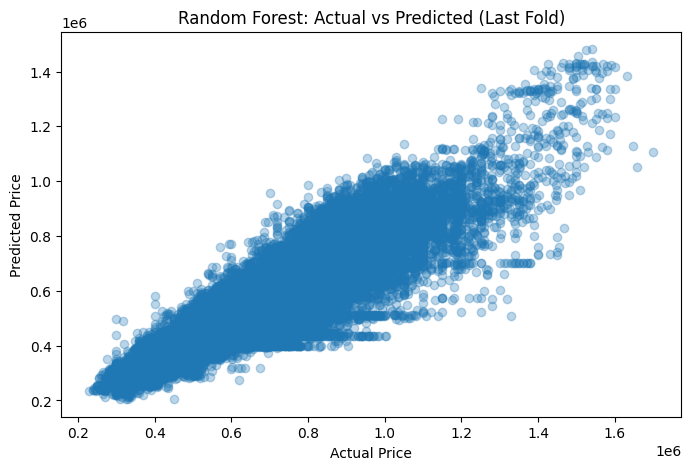

In [66]:
# =========================
# Visualisation (last fold)
# =========================

# Actual vs Predicted
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(last_y_test, last_y_pred_rf, alpha=0.3)
ax.set_title('Random Forest: Actual vs Predicted (Last Fold)')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')

plt.show()

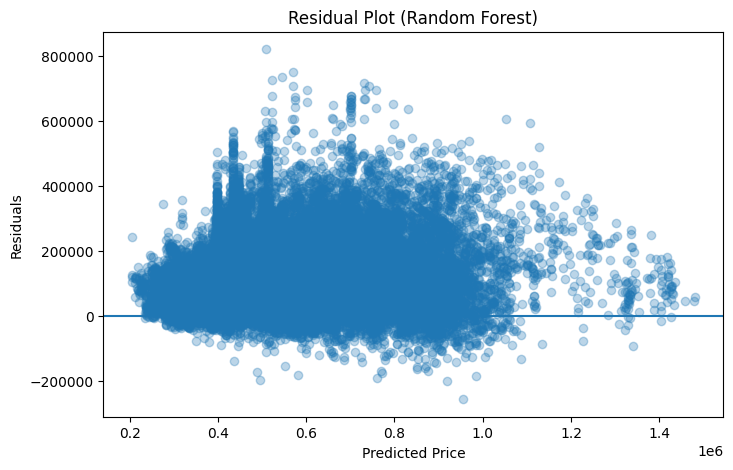

In [67]:
# Residual plot
residuals = last_y_test - last_y_pred_rf

fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(last_y_pred_rf, residuals, alpha=0.3)
ax.axhline(0)
ax.set_title('Residual Plot (Random Forest)')
ax.set_xlabel('Predicted Price')
ax.set_ylabel('Residuals')

plt.show()

In [68]:
# Feature Importance (RF)

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top Features:")
print(feature_importance.head(10))

Top Features:
                       Feature  Importance
1          num__floor_area_sqm    0.496518
2   num__remaining_lease_years    0.119765
0              num__storey_mid    0.116872
6        cat__town_BUKIT MERAH    0.032620
20        cat__town_QUEENSTOWN    0.023577
4             cat__town_BISHAN    0.018948
37        cat__flat_model_DBSS    0.016292
16   cat__town_KALLANG/WHAMPOA    0.014176
30       cat__flat_type_4 ROOM    0.012574
9       cat__town_CENTRAL AREA    0.011451


Random Forest outperformed Linear Regression, indicating non-linear relationships between features and resale prices.